In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

In [2]:
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler
import cup_common as cc
import nn_common as nnc
import cross_common as cr
import torch
import importlib
from functools import partial
import copy
from nn_common import FeatureTargetSet, HoldOutStrategy, EarlyStoppingStrategy
from cross_common import EPOCHS_VL_LOSS,FOLD_VL_LOSS,FOLD_TR_LOSS
from cross_common import MEE,MSE,RMSE,MAE,LOSS


importlib.reload(nnc)
importlib.reload(cc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h1>NN - Optuna</h1>
<h2>Exploring the cup dataset with NN Classifier with the help of Optuna tools.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [3]:
importlib.reload(cr)
df_train, df_test = cc.load_set()

# Scaler
scaler = StandardScaler()
# The train set used for model selection
# and final testing
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)


features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [4]:
# Set to True when model is selcted and assessed
dump_prediction = False

# The seed to be used by data splitter
default_state = 42
default_seed = 1

default_batch_size = [64]
default_epochs = 0

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 4

# fold strategy
base_fold_strategy = cr.common_fold_strategy(n_split=3)


# ---- The metrics to calculate in train ---
epochs_metrics_dict = {
    MSE: (cr.mse,min),
    MAE: (cr.mae,min)
}
the_metrics = epochs_metrics_dict.keys()
# ------------------------------------------


# ----- Defining model basic architecture --------
base_hidden_layers = ["32"]

# The output and loss function, must be changed according to the type of task
loss_function = nnc.MEELoss()
# activation function
base_activation_function = ["relu"]
output_adapter = nnc.regression_adapter()
# ------------------------------------------


# ----- Learning rate and weight decay -----
base_weight_decay = [0]
base_learning_rates = [1e-4]
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by which learning rate will decrease
learning_rate_decay_factor = 0.5    #0.6 #0.5
# The epoch to wait before applying the rate decay factor (must be lower than early stopping)
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", threshold_mode = "abs", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------

# Base trial dictionary to progressively update
base_trial_dict={
    "epochs": default_epochs,
    "batch_size": default_batch_size,
    "fold_strategy": base_fold_strategy,
    "input_dimension":input_dimension,
    "output_dimension":output_dimension,
    "hidden_layers": base_hidden_layers,
    "learning_rate": base_learning_rates,
    "weight_decay": base_weight_decay,
    "activation": base_activation_function,
    "output_adapter": output_adapter,
    "metrics": epochs_metrics_dict,
    "scheduler_template": scheduler_template
}

In [5]:
def objective(trial, X, y, trial_dict, objective_function):
    """
    Main objective function to be used with Optuna search.
    :param trial: the optuna trial object
    :param X: the feature
    :param y: the target
    :param trial_dict: the configuration dictionary
    :param objective_function: the objective function
    :return:
    """

    # PyTorch initizialization and mini-batch order change between trial.
    # To equally compare the hyper parameters we fix a common seed
    # at the beginning of the objective
    torch.manual_seed(default_seed)
    np.random.seed(default_seed)

    epochs_trial = trial_dict["epochs"]
    batch_size_trial = nnc.suggest_trial_param(trial, "batch_size", trial_dict["batch_size"])
    fold_strategy_trial = trial_dict["fold_strategy"]
    output_adapter_trial = trial_dict["output_adapter"]
    scheduler_template_trial = trial_dict.get("scheduler_template",None)
    hidden_layers_raw = nnc.suggest_trial_param(trial, "hidden_layers", trial_dict["hidden_layers"])
    hidden_layers_trial = [int(x) for x in hidden_layers_raw.split(",")]
    activation_trial = nnc.suggest_trial_param(trial,"activation", trial_dict["activation"])
    learning_rate_trial = nnc.suggest_trial_param(trial, "learning_rate", trial_dict["learning_rate"])
    weight_decay_trial = nnc.suggest_trial_param(trial, "weight_decay", trial_dict["weight_decay"])
    metrics_trial = trial_dict["metrics"]
    net_trial = nnc.build_nn_net(input_dimension, output_dimension, list(hidden_layers_trial), activation_trial)
    model_trial = nnc.build_nn_model(net_trial, output_adapter_trial)

    optimizer_template_trial = partial(
        torch.optim.AdamW,
        lr=learning_rate_trial,
        weight_decay=weight_decay_trial,
        betas=(0.95, 0.999)
    )

    inner_train_params_trial = {
        "epochs": epochs_trial,
        "batch_size": batch_size_trial,
        "scheduler_template": scheduler_template_trial,
        "optimizer_template": optimizer_template_trial,
        "loss_function": loss_function,
        "early_stopping_strategy": early_stopping_strategy,
        "silence_output": True,
        "additional_metrics": metrics_trial
    }

    return objective_function(
        nnc.kfold(model_trial, X, y, fold_strategy_trial, inner_train_params_trial, scaler)
    )


<h3>Optuna</h3>

<h4>Learning Rate</h4>
<hr>

<h5>Preparation</h5>

In [6]:

# partially instantiate evaluation funtion
evaluate_lr_partial = partial(
    nnc.evaluate_lr,
    epoch_metric=EPOCHS_VL_LOSS,
    fold_metric=FOLD_VL_LOSS,
    early_epoch=30
)

coarse_learning_rates = [1e-4, 5e-4, 1e-3, 2e-3, 3e-3]

<h5>Coarse Grained</h5>

In [7]:
# as we are testing few lr a small
# nr of trials is enough
coarse_grained_trials_nr = 20

base_trial_dict["learning_rate"] = coarse_learning_rates
base_trial_dict["epochs"] = 100

objective_coarse_grained_lr_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_lr_partial,
    trial_dict=base_trial_dict
)

coarse_grained_lr_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize", "maximize"],
    pruner=optuna.pruners.MedianPruner()
)

coarse_grained_lr_study.optimize(objective_coarse_grained_lr_partial, show_progress_bar=True, n_trials=coarse_grained_trials_nr)

[I 2026-08-12 15:12:49,681] A new study created in memory with name: no-name-36b56733-7377-40de-a9bf-0b506a68e5cd
  5%|▌         | 1/20 [00:03<01:02,  3.27s/it]

[I 2026-08-12 15:12:52,975] Trial 0 finished with values: [25.262006721068172, 0.1141567369918393, 0.20970706915452253] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.001, 'weight_decay': 0}.


 10%|█         | 2/20 [00:05<00:47,  2.64s/it]

[I 2026-08-12 15:12:55,166] Trial 1 finished with values: [25.585657573757103, 0.043286950433353656, 0.10226670090729684] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0005, 'weight_decay': 0}.


 15%|█▌        | 3/20 [00:07<00:40,  2.38s/it]

...

[I 2026-08-12 15:13:28,429] Trial 17 finished with values: [24.652136973143513, 0.18205120423695062, 0.27577394439169883] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.002, 'weight_decay': 0}.


 95%|█████████▌| 19/20 [00:40<00:02,  2.08s/it]

[I 2026-08-12 15:13:30,510] Trial 18 finished with values: [24.652136973143513, 0.18205120423695062, 0.27577394439169883] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.002, 'weight_decay': 0}.


100%|██████████| 20/20 [00:44<00:00,  2.23s/it]

[I 2026-08-12 15:13:34,275] Trial 19 finished with values: [24.652136973143513, 0.18205120423695062, 0.27577394439169883] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.002, 'weight_decay': 0}.


In [8]:
coarse_grained_lr = nnc.find_best_lr_from_trials(coarse_grained_lr_study)
print(f"lr: {coarse_grained_lr}")

lr: 0.003


<h5>Fine Grained</h5>

In [9]:
# the number of trials depends on the
# suggestion returned by optuna
fine_grained_trials_nr=30

# Build a fine-grained search range around the best coarse learning rate
# by scaling it with a constant factor (lr / factor, lr * factor).
# This refines the search locally on a logarithmic scale.
# if coarse lr = 0.001 --> interval = (0.00033 , 0.003)
# (optuna will return --> [0.00033, 0.00045,0.00060,0.00080,0.00105,0.00140,0.00190,0.00250,0.003] )
constant_lr_factor = 3
low_lr = coarse_grained_lr / constant_lr_factor
high_lr = coarse_grained_lr * constant_lr_factor

base_trial_dict["learning_rate"] = (low_lr, high_lr)
base_trial_dict["epochs"] = 100

objective_fine_grained_lr_partial = partial(
    objective, X=X_tr, y=y_tr, objective_function = evaluate_lr_partial,
    trial_dict=base_trial_dict
)

fine_grained_lr_study = optuna.create_study(
    # same reason for "directions"
    directions=["minimize", "minimize", "maximize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_lr_study.optimize(objective_fine_grained_lr_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)

[I 2026-08-12 15:13:34,343] A new study created in memory with name: no-name-1689091c-0540-477d-98a2-64b190768fc4
  3%|▎         | 1/30 [00:02<01:00,  2.09s/it]

[I 2026-08-12 15:13:36,432] Trial 0 finished with values: [23.893934214696813, 0.3190725715616906, 0.27283223229207826] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.006032308034494402, 'weight_decay': 0}.


  7%|▋         | 2/30 [00:04<00:58,  2.08s/it]

[I 2026-08-12 15:13:38,514] Trial 1 finished with values: [24.44803990983597, 0.20057563892122351, 0.27612338643231515] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.002380437003761913, 'weight_decay': 0}.


 10%|█         | 3/30 [00:06<00:56,  2.07s/it]

...

[I 2026-08-12 15:14:34,759] Trial 27 finished with values: [25.07595942366322, 0.13978315139051656, 0.258325717804129] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0013086158805071125, 'weight_decay': 0}.


 97%|█████████▋| 29/30 [01:02<00:02,  2.11s/it]

[I 2026-08-12 15:14:36,829] Trial 28 finished with values: [23.88212837923044, 0.31268709880384354, 0.272881092060347] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.005766702514616703, 'weight_decay': 0}.


100%|██████████| 30/30 [01:04<00:00,  2.15s/it]

[I 2026-08-12 15:14:38,914] Trial 29 finished with values: [24.338096355550793, 0.21216026969403434, 0.2759538662481386] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0026405190257083678, 'weight_decay': 0}.


In [10]:
final_lr = nnc.find_best_lr_from_trials(fine_grained_lr_study)
base_trial_dict["learning_rate"] = [final_lr]
print(coarse_grained_lr, final_lr)

0.003 0.008206725313798213


<h4>Batch Size</h4>
<hr>

In [11]:
evaluate_batch_size_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS
)

# online and batch are excluded as they respectively noisy and inefficient
batch_sizes = [16, 32, 64, 128]

In [12]:
# as we are testing few lr a small
# nr of trials is enough
batch_sizes_trials_nr = 20

base_trial_dict["batch_size"] = batch_sizes
base_trial_dict["epochs"] = 500 # <-- increasing epochs for the rest of the studies

objective_batch_size_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_batch_size_partial,
    trial_dict=base_trial_dict
)

batch_size_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)

batch_size_study.optimize(objective_batch_size_partial, show_progress_bar=True, n_trials=batch_sizes_trials_nr)

[I 2026-08-12 15:14:38,995] A new study created in memory with name: no-name-aaefc890-6897-45bb-a306-086dff94a9d5
  5%|▌         | 1/20 [00:09<03:07,  9.85s/it]

[I 2026-08-12 15:14:48,849] Trial 0 finished with values: [22.99911491991801, 1.2640992041125187] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 0}.


 10%|█         | 2/20 [00:15<02:12,  7.35s/it]

[I 2026-08-12 15:14:54,454] Trial 1 finished with values: [23.124997309905908, 0.9562352790065525] and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 0}.


 15%|█▌        | 3/20 [00:19<01:38,  5.82s/it]

...

[I 2026-08-12 15:16:15,946] Trial 17 finished with values: [23.22443282014521, 0.9683511338773947] and parameters: {'batch_size': 128, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 0}.


 95%|█████████▌| 19/20 [01:40<00:04,  4.22s/it]

[I 2026-08-12 15:16:19,501] Trial 18 finished with values: [23.22443282014521, 0.9683511338773947] and parameters: {'batch_size': 128, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 0}.


100%|██████████| 20/20 [01:45<00:00,  5.29s/it]

[I 2026-08-12 15:16:24,872] Trial 19 finished with values: [23.124997309905908, 0.9562352790065525] and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 0}.


In [13]:
importlib.reload(nnc)
final_batch_size = nnc.find_best_batch_size_from_trials(batch_size_study)
base_trial_dict["batch_size"] = [final_batch_size]
print(final_batch_size)

16


<h4>Weight Decay</h4>
<hr>

<h5>Preparation</h5>

In [14]:

evaluate_wd_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS
)

coarse_weight_decays = [0.0, 1e-5, 1e-4, 5e-4]

<h5>Coarse Grained</h5>

In [15]:
coarse_grained_wd_trials_nr = 20

base_trial_dict["weight_decay"] = coarse_weight_decays

objective_coarse_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict=base_trial_dict
)

coarse_grained_wd_study = optuna.create_study(
    # minimize according to find_best_weight_decay_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
coarse_grained_wd_study.optimize(objective_coarse_grained_wd_partial, show_progress_bar=True, n_trials=coarse_grained_wd_trials_nr)

[I 2026-08-12 15:16:24,952] A new study created in memory with name: no-name-a27a9781-e839-4654-8e5b-09b00401775c
  5%|▌         | 1/20 [00:08<02:47,  8.84s/it]

[I 2026-08-12 15:16:33,787] Trial 0 finished with values: [22.979544416047407, 1.2908227604885383] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 1e-05}.


 10%|█         | 2/20 [00:17<02:33,  8.50s/it]

[I 2026-08-12 15:16:42,060] Trial 1 finished with values: [22.99911491991801, 1.2640992041125187] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 0.0}.


 15%|█▌        | 3/20 [00:25<02:23,  8.42s/it]

...

[I 2026-08-12 15:18:59,399] Trial 17 finished with values: [22.979544416047407, 1.2908227604885383] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 1e-05}.


 95%|█████████▌| 19/20 [02:42<00:08,  8.67s/it]

[I 2026-08-12 15:19:07,875] Trial 18 finished with values: [23.00074210397535, 1.182654940401612] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 0.0005}.


100%|██████████| 20/20 [02:51<00:00,  8.59s/it]

[I 2026-08-12 15:19:16,683] Trial 19 finished with values: [22.979544416047407, 1.2908227604885383] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 1e-05}.


In [16]:
coarse_weight_decay = nnc.find_best_weight_decay_from_trials(coarse_grained_wd_study)
print(coarse_weight_decay)

1e-05


<h5>Fine Grained</h5>

In [17]:
fine_grained_wd_trials_nr = 35

if coarse_weight_decay > 0:
    low_wd = max(coarse_weight_decay / constant_lr_factor, min(coarse_weight_decays))
    high_wd = min(coarse_weight_decay * constant_lr_factor, max(coarse_weight_decays))

    base_trial_dict["weight_decay"] = (low_wd, high_wd)

    objective_fine_grained_wd_partial = partial(
        objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
        trial_dict=base_trial_dict
    )

    fine_grained_wd_study = optuna.create_study(
        # same as before...
        directions=["minimize", "minimize"],
        pruner=optuna.pruners.MedianPruner()
    )
    fine_grained_wd_study.optimize(objective_fine_grained_wd_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)


[I 2026-08-12 15:19:16,834] A new study created in memory with name: no-name-59317f8d-31bc-4097-957f-0caf9697bf51
  3%|▎         | 1/30 [00:08<04:17,  8.90s/it]

[I 2026-08-12 15:19:25,731] Trial 0 finished with values: [22.979544416047407, 1.2908227604885383] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 7.602391755113964e-06}.


  7%|▋         | 2/30 [00:17<04:07,  8.84s/it]

[I 2026-08-12 15:19:34,532] Trial 1 finished with values: [22.979544416047407, 1.2908227604885383] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 9.714498861840641e-06}.


 10%|█         | 3/30 [00:26<03:59,  8.86s/it]

...

[I 2026-08-12 15:23:32,929] Trial 27 finished with values: [22.97972849645051, 1.2910558487063852] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 5.505879460659077e-06}.


 97%|█████████▋| 29/30 [04:25<00:10, 10.71s/it]

[I 2026-08-12 15:23:42,732] Trial 28 finished with values: [22.97730913174387, 1.2912629805235483] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 2.162940400422489e-05}.


100%|██████████| 30/30 [04:34<00:00,  9.16s/it]

[I 2026-08-12 15:23:51,565] Trial 29 finished with values: [22.97440660837807, 1.2887924681646972] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 1.2402975840710859e-05}.


In [18]:
if coarse_weight_decay > 0:
    final_weight_decay = nnc.find_best_weight_decay_from_trials(fine_grained_wd_study)
elif coarse_weight_decay == 0:
    final_weight_decay = 0
else:
    raise ValueError("coarse_weight_decay must be 0 or greater")

base_trial_dict["weight_decay"] = [final_weight_decay]
print(f"Coarse grained WD: {coarse_weight_decay} Fine grained WD: {final_weight_decay}")

Coarse grained WD: 1e-05 Fine grained WD: 1.6183611167820987e-05


<h4>Model Architecture</h4>
<hr/>

In [21]:
architecture_trials_nr=40

evaluate_architecture_partial = partial(
    nnc.evaluate_architecture,
    tr_key=FOLD_TR_LOSS,
    vl_key=FOLD_VL_LOSS
)

base_trial_dict["activation"] = ["relu", "tanh", "gelu"]
base_trial_dict["hidden_layers"] = base_hidden_layers + [
    "64",
    "128",
    "256",
    "64,32",
    "128,64",
    "256,128",
    "256,64",
    "64,64",
    "128,128",
    "64,32,16",
    "128,64,32",
    "256,128,64",
]
base_trial_dict["fold_strategy"] = cr.common_fold_strategy(n_split=5)

objective_fine_grained_model = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_architecture_partial,
    trial_dict=base_trial_dict
)

model_study = optuna.create_study(
    # see find_best_architecture_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
model_study.optimize(objective_fine_grained_model, show_progress_bar=True, n_trials=architecture_trials_nr)



[I 2026-08-12 15:29:26,757] A new study created in memory with name: no-name-323ee8df-405f-4aa6-95c1-d06905446be5
  2%|▎         | 1/40 [00:16<10:31, 16.20s/it]

[I 2026-08-12 15:29:42,963] Trial 0 finished with values: [20.340031921386718, 5.806045364379882] and parameters: {'batch_size': 16, 'hidden_layers': '64,64', 'activation': 'tanh', 'learning_rate': 0.008206725313798213, 'weight_decay': 1.6183611167820987e-05}.


  5%|▌         | 2/40 [00:30<09:41, 15.31s/it]

[I 2026-08-12 15:29:57,656] Trial 1 finished with values: [21.959523605346682, 2.211223403930667] and parameters: {'batch_size': 16, 'hidden_layers': '256', 'activation': 'gelu', 'learning_rate': 0.008206725313798213, 'weight_decay': 1.6183611167820987e-05}.


  8%|▊         | 3/40 [00:47<09:55, 16.10s/it]

...

[I 2026-08-12 15:38:58,287] Trial 37 finished with values: [20.746397994995114, 5.899516716003415] and parameters: {'batch_size': 16, 'hidden_layers': '128,64', 'activation': 'gelu', 'learning_rate': 0.008206725313798213, 'weight_decay': 1.6183611167820987e-05}.


 98%|█████████▊| 39/40 [09:45<00:14, 14.52s/it]

[I 2026-08-12 15:39:12,749] Trial 38 finished with values: [21.959523605346682, 2.211223403930667] and parameters: {'batch_size': 16, 'hidden_layers': '256', 'activation': 'gelu', 'learning_rate': 0.008206725313798213, 'weight_decay': 1.6183611167820987e-05}.


100%|██████████| 40/40 [10:01<00:00, 15.04s/it]

[I 2026-08-12 15:39:28,325] Trial 39 finished with values: [22.355301841735844, 1.922522865295413] and parameters: {'batch_size': 16, 'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.008206725313798213, 'weight_decay': 1.6183611167820987e-05}.


In [27]:
importlib.reload(nnc)
final_hidden_layers, final_activation, best_vl, gap_tr_vl = nnc.find_best_architecture_from_trials(model_study)
base_trial_dict["hidden_layers"] = [", ".join(map(str, final_hidden_layers))]
print(f"Final layers: {final_hidden_layers}  Activation: {final_activation} - best metrics: {best_vl} - best VL/TR gap: {gap_tr_vl}")


Final layers: [256, 128, 64]  Activation: gelu - best metrics: 20.205857582092285 - best VL/TR gap: 8.966828763961791


<h3>KFold</h3>
<p>The selected configuration is evaluated again using fold cross-validation to summarize its performance and training dynamics. Since the same development set was used during hyperparameter selection, this is not an independent nested assessment.</p>
<hr/>

<h4>Run</h4>

In [28]:
importlib.reload(nnc)
importlib.reload(cc)

# The KFold strategy to be used through all models
fold_strategy = cr.common_fold_strategy()
net = nnc.build_nn_net(input_dimension, output_dimension, final_hidden_layers, final_activation)
model_template = nnc.build_nn_model(net, output_adapter)

overfitting_treshold = 1e-2

# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=final_lr,
    weight_decay=final_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------

# Epochs
kv_epochs=1000
kv_batch_size=final_batch_size
#kv_batch_size="batch"

inner_train_params = {
    "epochs": kv_epochs,
    "batch_size": kv_batch_size,
    # We apply lr decay only if gap_tr_vl is greater than treshold
    "scheduler_template": None if gap_tr_vl < overfitting_treshold else scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy,
    "additional_metrics": epochs_metrics_dict,
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, fold_strategy, inner_train_params, scaler
)

  
Perform fold: 0, train size: 400, val size: 100
Early stopping at epoch 111 (best VL loss: 19.9821)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 400
Validation      | samples: 100
Batch type      | mini-batch (16)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.008206725313798213, 'weight_decay': 1.6183611167820987e-05, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'threshold_mode': 'abs', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | best epoch: 62 metric: loss,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 400, val size: 100
Early stopping at epoch 80 (best VL loss: 18.7202)
Train summary
----------------------

<h5>Metric</h5>
<p>Main metric evaluated for model assessment.
</p>

In [30]:
display(cr.kfold_summary(fold_histories, use=LOSS))

,TR,VL,|TR-VL|
Fold,,,
1,6.894081,19.982095,13.088014
2,13.893092,18.720157,4.827065
3,9.009845,19.046671,10.036826
4,7.161252,21.558518,14.397265
5,11.677589,20.392732,8.715143
MEAN,9.727172,19.940035,10.212863
STD,2.693842,1.011177,3.378067


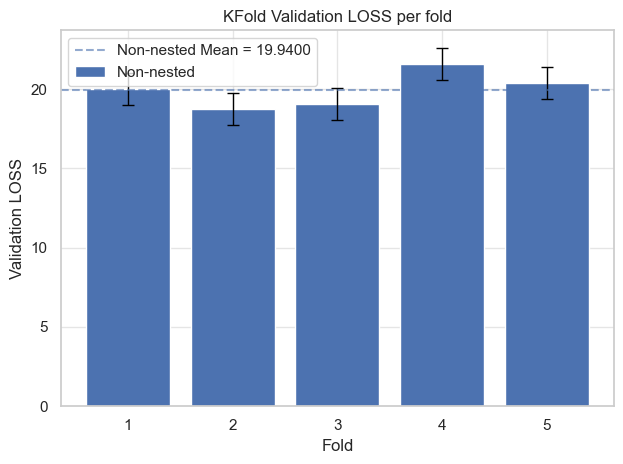

,TR,VL,|TR-VL|
Fold,,,
1,6.894081,19.982095,13.088014
2,13.893092,18.720157,4.827065
3,9.009845,19.046671,10.036826
4,7.161252,21.558518,14.397265
5,11.677589,20.392732,8.715143
MEAN,9.727172,19.940035,10.212863
STD,2.693842,1.011177,3.378067


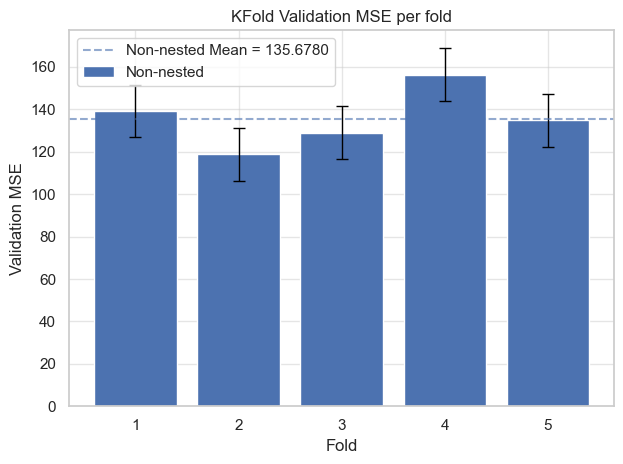

,TR,VL,|TR-VL|
Fold,,,
1,22.524642,139.302459,116.777817
2,75.896888,118.866996,42.970109
3,35.526393,128.968686,93.442292
4,109.985090,156.394292,46.409202
5,80.517181,134.857354,54.340172
MEAN,64.890039,135.677957,70.787918
STD,31.799285,12.414505,29.212915


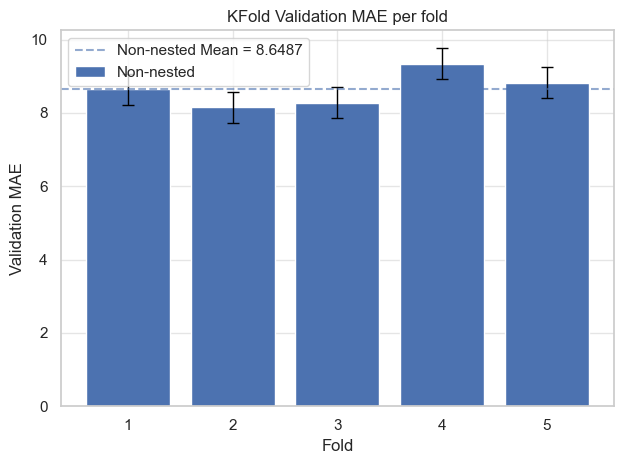

,TR,VL,|TR-VL|
Fold,,,
1,3.161172,8.648870,5.487698
2,3.078401,8.152541,5.074140
3,3.874496,8.274852,4.400355
4,3.066825,9.338388,6.271563
5,5.084904,8.828705,3.743801
MEAN,3.653160,8.648671,4.995511
STD,0.776540,0.422849,0.871519


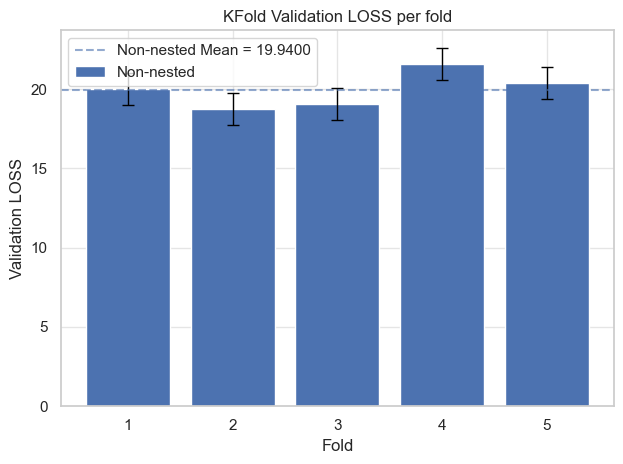

,TR,VL,|TR-VL|
Fold,,,
1,6.894081,19.982095,13.088014
2,13.893092,18.720157,4.827065
3,9.009845,19.046671,10.036826
4,7.161252,21.558518,14.397265
5,11.677589,20.392732,8.715143
MEAN,9.727172,19.940035,10.212863
STD,2.693842,1.011177,3.378067


In [31]:
importlib.reload(cr)

# LOSS is always present
cr.plot_kfold_metric([(fold_histories,"Non-nested")], LOSS)
display(cr.kfold_summary(fold_histories, use=LOSS))

for metric in the_metrics:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_summary(fold_histories, use=metric))


<h3>Best Hyperparameters</h3>
<hr/>

In [32]:
print(f"hidden layers: {final_hidden_layers}")
print(f"activation function: {final_activation}")
for key, value in inner_train_params.items():
    print(f"{key}: {value}")

hidden layers: [256, 128, 64]
activation function: gelu
epochs: 1000
batch_size: 16
scheduler_template: functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', threshold_mode='abs', factor=0.5, patience=10, threshold=0.01)
optimizer_template: functools.partial(<class 'torch.optim.adamw.AdamW'>, lr=0.008206725313798213, weight_decay=1.6183611167820987e-05, betas=(0.95, 0.999))
loss_function: MEELoss(reduction='mean') - custom function
early_stopping_strategy: EarlyStopping monitoring loss with patience=50, min_delta=0.01
additional_metrics: {'mse': (<function mse at 0x120193950>, <built-in function min>), 'mae': (<function mae at 0x120193c10>, <built-in function min>), 'loss': (MEELoss(reduction='mean') - custom function, <built-in function min>)}
